# 贝叶斯回归就是线性回归的扩展，可以处理高斯分布的回归问题。其模型通过贝叶斯方法来估计回归系数，并给出回归系数的预测的置信区间，同时对预测值y给出预测的方差。

开始加载数据集...
无法加载加利福尼亚房价数据集: HTTP Error 403: Forbidden
无法加载波士顿房价数据集: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=

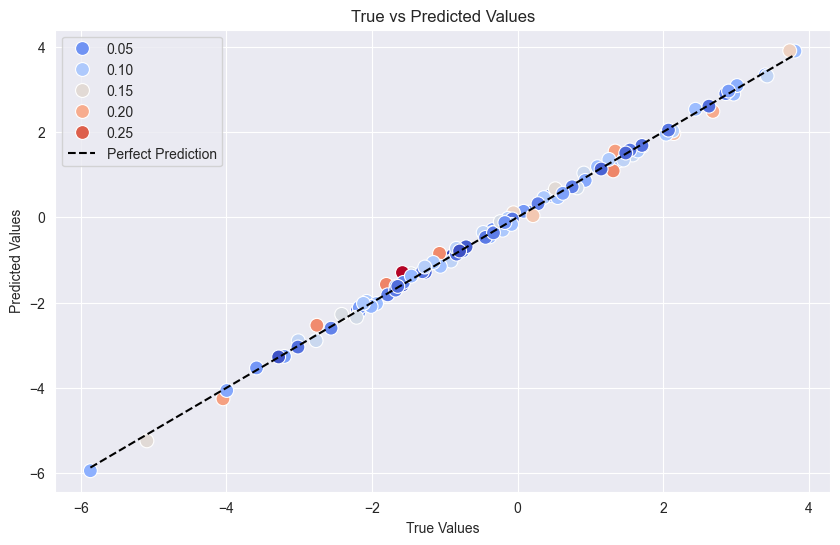

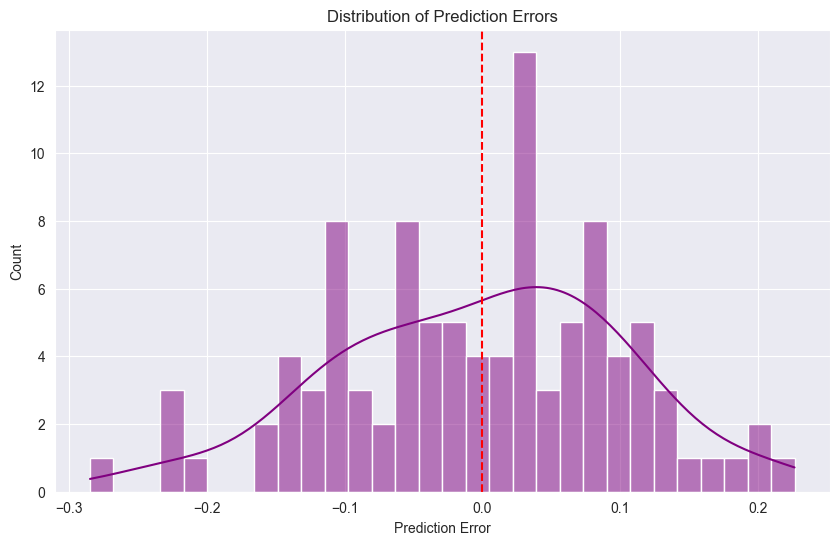

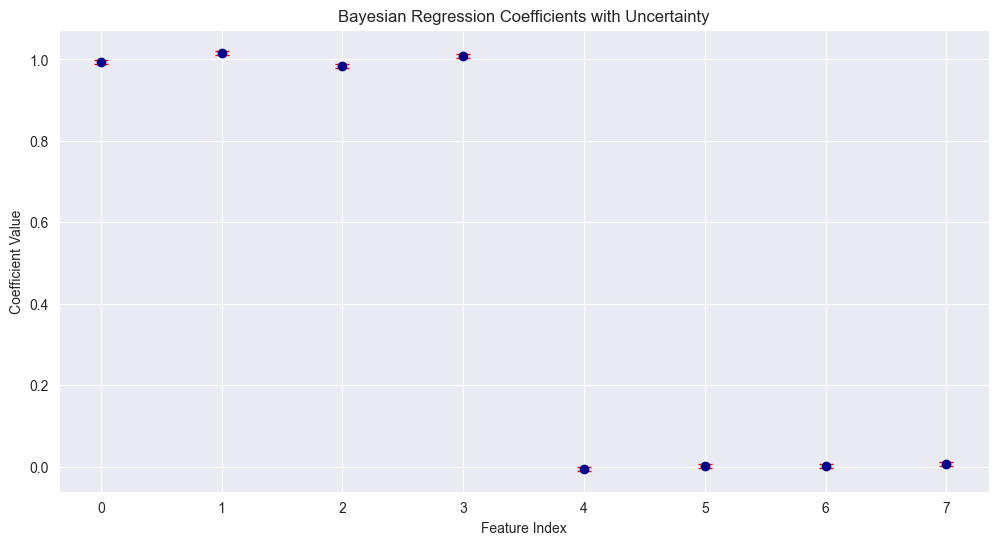

所有步骤执行完毕


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score

print("开始加载数据集...")
# 尝试多种数据集加载方式
X, y = None, None
datasets_tried = []

# 方法1: 尝试加载加利福尼亚房价数据集
try:
    from sklearn.datasets import fetch_california_housing
    california = fetch_california_housing()
    X, y = california.data, california.target
    print("成功加载加利福尼亚房价数据集")
    datasets_tried.append("California Housing")
except Exception as e:
    print(f"无法加载加利福尼亚房价数据集: {e}")
    datasets_tried.append(f"California Housing (失败: {str(e)[:50]}...)")

# 方法2: 尝试加载波士顿房价数据集
if X is None:
    try:
        from sklearn.datasets import load_boston
        boston = load_boston()
        X, y = boston.data, boston.target
        print("成功加载波士顿房价数据集")
        datasets_tried.append("Boston Housing")
    except Exception as e:
        print(f"无法加载波士顿房价数据集: {e}")
        datasets_tried.append(f"Boston Housing (失败: {str(e)[:50]}...)")

# 方法3: 创建模拟数据
if X is None:
    print("使用模拟数据")
    datasets_tried.append("模拟数据")
    np.random.seed(42)
    X = np.random.randn(500, 8)
    y = np.sum(X[:, :4], axis=1) + np.random.randn(500) * 0.1

print(f"尝试过的数据集: {', '.join(datasets_tried)}")
print(f"数据形状: X={X.shape}, y={y.shape}")

try:
    # 2. 数据标准化 & 拆分训练/测试集
    print("正在进行数据预处理...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    print("数据预处理完成")

    # 3. 训练贝叶斯回归模型
    print("开始训练贝叶斯回归模型...")
    model = BayesianRidge(tol=1e-6, alpha_1=1e-6, lambda_1=1e-6)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("模型训练完成")

    # 4. 计算误差指标
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'MSE: {mse:.3f}, R^2: {r2:.3f}')

    # 5. 预测 vs 真实值 可视化
    print("生成可视化图表...")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, hue=np.abs(y_test - y_pred), palette='coolwarm', s=100)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--k', label='Perfect Prediction')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('True vs Predicted Values')
    plt.legend()
    plt.show()

    # 6. 误差分布
    plt.figure(figsize=(10, 6))
    sns.histplot(y_test - y_pred, kde=True, bins=30, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel('Prediction Error')
    plt.title('Distribution of Prediction Errors')
    plt.show()

    # 7. 置信区间可视化
    coefs_mean = model.coef_
    coefs_std = np.sqrt(np.diag(model.sigma_))

    plt.figure(figsize=(12, 6))
    plt.errorbar(range(len(coefs_mean)), coefs_mean, yerr=coefs_std, fmt='o', color='darkblue', ecolor='red', capsize=5)
    plt.xlabel('Feature Index')
    plt.ylabel('Coefficient Value')
    plt.title('Bayesian Regression Coefficients with Uncertainty')
    plt.show()

    print("所有步骤执行完毕")

except Exception as e:
    print(f"发生错误: {e}")
    import traceback
    traceback.print_exc()
